# Trabajo Practico Nº3 - PDI (Grupo 6)
Integrantes: Añaños Diego, Quinteros Facundo, Lasarte Roberto

# 0. Importaciónes de Librerias a Usar

In [1]:
import os
import cv2
import math
import random
import numpy as np
import matplotlib.pyplot as plt

# 1. Problema - Cinco dados

In [15]:
# Diccionario para almacenar los datos de cada video para usar a lo largo del notebook
videos = ['tirada_1.mp4', 'tirada_2.mp4', 'tirada_3.mp4', 'tirada_4.mp4']
videos_data = {}

for idx, path in enumerate(videos):
    cap = cv2.VideoCapture(path)
    if not cap.isOpened():
        print(f"Error al abrir el video: {path}")
        continue
    
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    # Leer todos los frames para procesamiento posterior
    frames = []
    while True:
        ret, frame = cap.get(cv2.CAP_PROP_POS_FRAMES), cap.read()[1]
        if frame is None:
            break
        frames.append(frame)
        
    cap.release()
    
    videos_data[f"video_{idx+1}"] = {
        "path": path,
        "frames": frames,
        "fps": fps,
        "frame_count": frame_count,
        "size": (width, height)
    }
    print(f"Video {idx+1} cargado: {frame_count} frames, {width}x{height} a {fps:.2f} FPS")

Video 1 cargado: 146 frames, 1080x2224 a 30.00 FPS
Video 2 cargado: 145 frames, 1080x2224 a 30.00 FPS
Video 3 cargado: 146 frames, 1080x2224 a 30.00 FPS
Video 4 cargado: 88 frames, 1080x2224 a 30.00 FPS


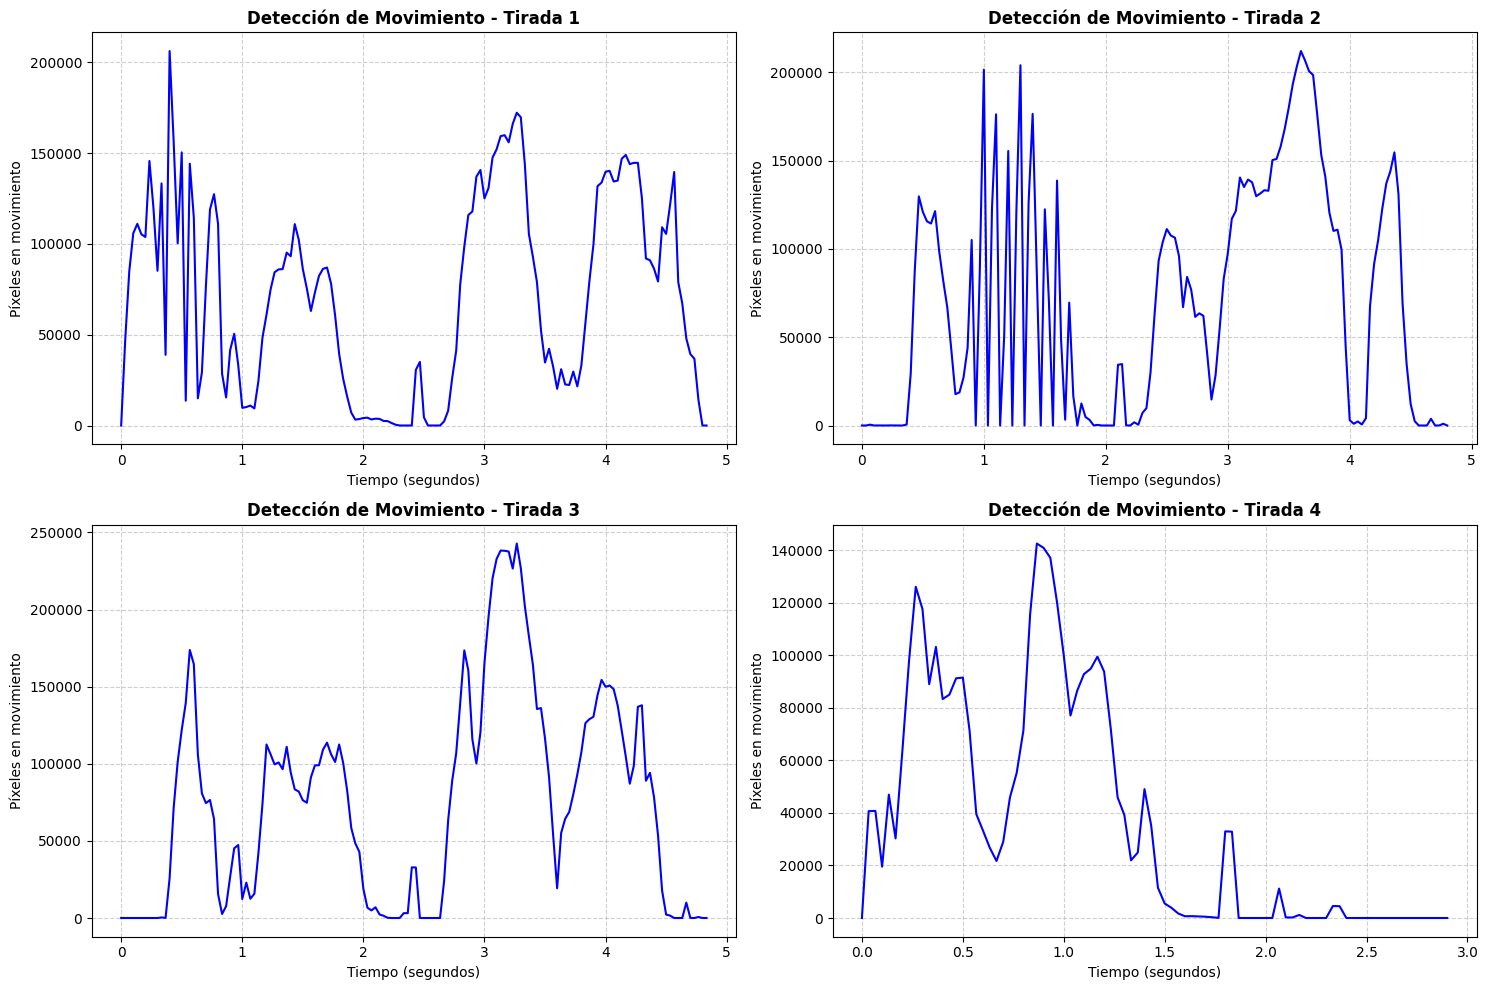

In [36]:
# --- CONFIGURACIÓN DE PARÁMETROS ---
UMBRAL_BINARIO = 25  # Sensibilidad al cambio de color por píxel
MIN_AREA_MOVIMIENTO = 50  # Filtro para ignorar ruido

# Diccionario para guardar las curvas de movimiento de cada video
movimientos_por_video = {}

for key, data in videos_data.items():
    frames = data["frames"]
    movimiento_por_frame = []
    
    # al menos 2 frames para calcular movimiento
    if len(frames) < 2: 
        print(f"El {key} no tiene suficientes frames.")
        continue
        
    # Inicializar el primer frame en escala de grises y con Blur para reducir ruido
    prev_gray = cv2.cvtColor(frames[0], cv2.COLOR_BGR2GRAY)
    prev_gray = cv2.GaussianBlur(prev_gray, (21, 21), 0)
    
    # El primer frame no tiene "anterior", asumimos movimiento 0
    movimiento_por_frame.append(0)
    
    for i in range(1, len(frames)):
        # Pasar frame actual a grises y aplicar blur
        gray = cv2.cvtColor(frames[i], cv2.COLOR_BGR2GRAY)
        gray = cv2.GaussianBlur(gray, (21, 21), 0)
        
        # 1. Diferencia absoluta entre el frame actual y el anterior
        frame_delta = cv2.absdiff(prev_gray, gray)
        
        # 2. Umbralizado para binarizar el movimiento (blanco = movimiento, negro = estático)
        thresh = cv2.threshold(frame_delta, UMBRAL_BINARIO, 255, cv2.THRESH_BINARY)[1]
        
        # 3. Dilatar la imagen para rellenar huecos
        thresh = cv2.dilate(thresh, None, iterations=2)
        
        # 4. Calcular la cantidad de movimiento (sumando los píxeles blancos)
        # También podés contar el área total de los contornos detectados
        píxeles_movimiento = np.sum(thresh == 255)
        movimiento_por_frame.append(píxeles_movimiento)
        
        # Actualizar el frame anterior para la siguiente iteración
        prev_gray = gray
        
    movimientos_por_video[key] = movimiento_por_frame

# --- GENERACIÓN DEL SUBPLOT ---
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=False)
axes = axes.ravel()  # Aplanar la matriz de 2x2 a un array de 4 elementos

for idx, (key, data) in enumerate(videos_data.items()):
    ax = axes[idx]
    movimiento = movimientos_por_video.get(key, [])
    
    # Crear un vector de tiempo en segundos para que sea más intuitivo
    fps = data["fps"]
    tiempo = [f / fps for f in range(len(movimiento))]
    
    # Graficar la curva de movimiento
    ax.plot(tiempo, movimiento, color='b', linewidth=1.5, label='Intensidad de Movimiento')
    
    # Estética del gráfico
    ax.set_title(f"Detección de Movimiento - Tirada {idx+1}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Tiempo (segundos)", fontsize=10)
    ax.set_ylabel("Píxeles en movimiento", fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Video_1: Se encontraron 15 frames estables. Elegido el frame #74
Video_2: Se encontraron 37 frames estables. Elegido el frame #50
Video_3: Se encontraron 33 frames estables. Elegido el frame #70
Video_4: Se encontraron 36 frames estables. Elegido el frame #70


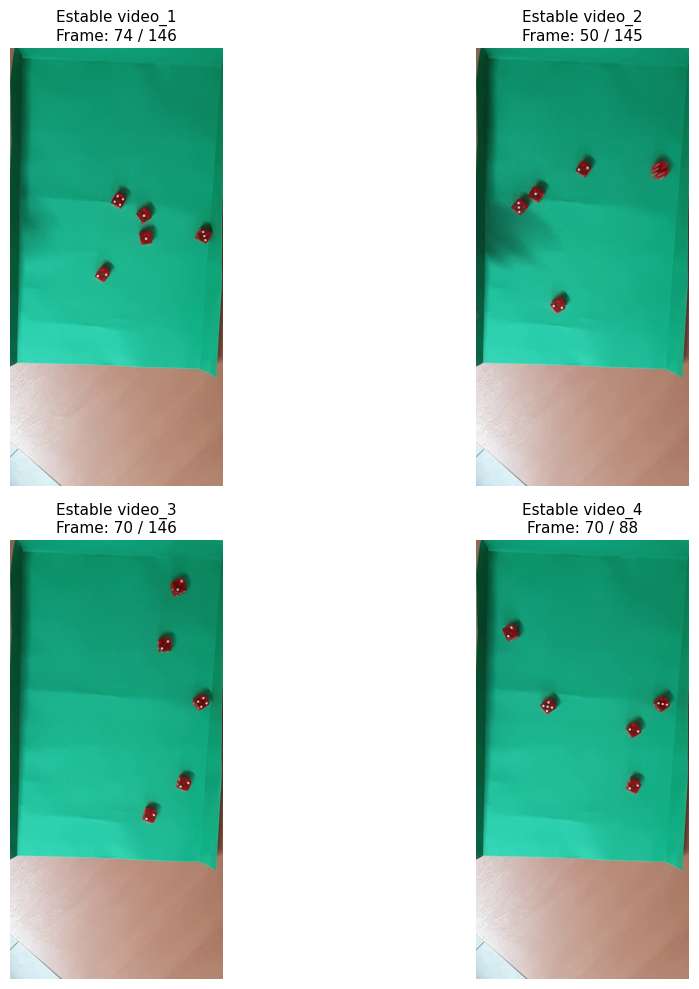

In [ ]:
# --- CONFIGURACIÓN ---
THRESHOLD_MOTION = 500  # umbral para considerar "sin movimiento"

# Diccionario para guardar el índice del frame estable elegido de cada video
stable_frame_indices = {}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, (key, data) in enumerate(videos_data.items()):
    ax = axes[idx]
    frames = data["frames"]
    motion_scores = movimientos_por_video.get(key, [])
    
    # 1. Encontrar todos los índices donde el movimiento es menor al umbral
    stable_indices = [i for i, m in enumerate(motion_scores) if m < THRESHOLD_MOTION]
    
    if not stable_indices:
        print(f"No se encontraron frames estables para {key} con el umbral {THRESHOLD_MOTION}")
        ax.text(0.5, 0.5, f"Sin frames estables\n{key}", ha='center', va='center')
        ax.axis('off')
        continue
    
    # queremos el frame FINAL (después de la tirada), 
    # es mejor elegir un frame representativo de la ÚLTIMA racha estable.
    # el del medio de los estables encontrados.
    chosen_frame_idx = stable_indices[len(stable_indices) // 2]
    stable_frame_indices[key] = chosen_frame_idx
    
    # Guardar también el índice en la estructura principal por si lo necesitás después
    videos_data[key]["stable_frame_idx"] = chosen_frame_idx
    
    # 2. Graficar el frame seleccionado
    stable_frame = frames[chosen_frame_idx]
    ax.imshow(cv2.cvtColor(stable_frame, cv2.COLOR_BGR2RGB))
    ax.set_title(f"Estable {key}\nFrame: {chosen_frame_idx} / {data['frame_count']}", fontsize=11)
    ax.axis("off")
    
    print(f"{key.capitalize()}: Se encontraron {len(stable_indices)} frames estables. Elegido el frame #{chosen_frame_idx}")

plt.tight_layout()
plt.show()

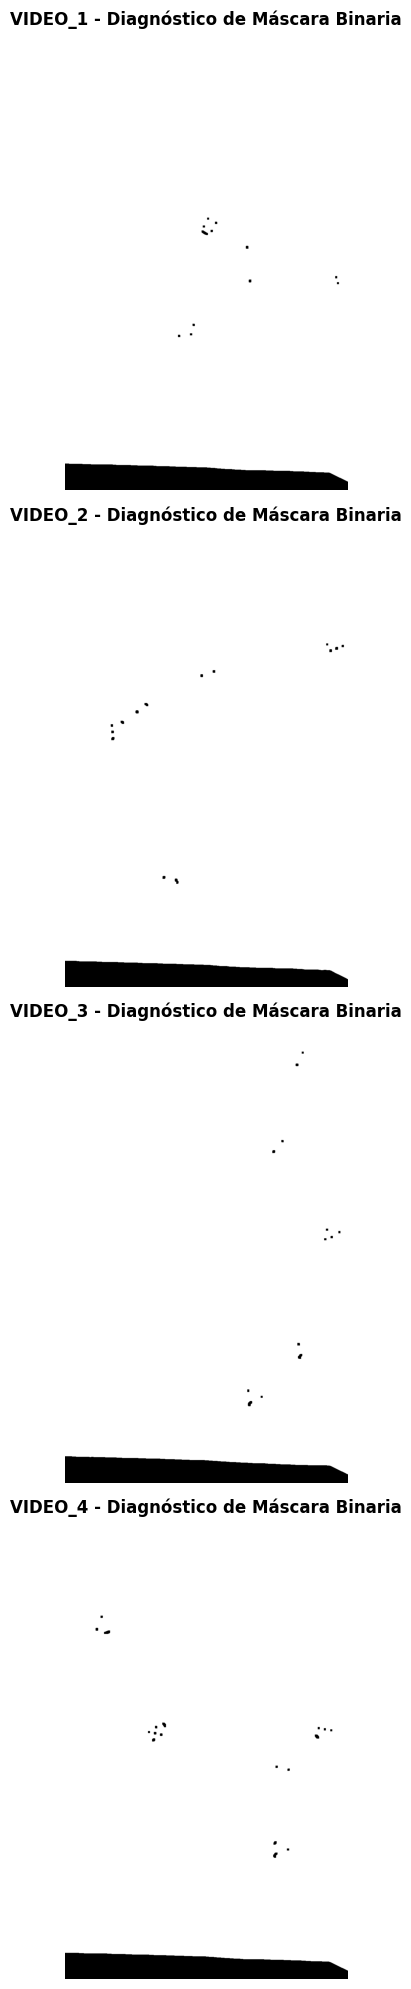

In [ ]:
# Diccionario para verificar las máscaras visualmente
mascaras_diagnostico = {}
fig, axes = plt.subplots(4, 1, figsize=(10, 20))

for idx, (key, data) in enumerate(videos_data.items()):
    ax = axes[idx]
    
    stable_idx = data.get("stable_frame_idx")
    if stable_idx is None: continue
        
    frame = data["frames"][stable_idx]
    h_orig, w_orig, _ = frame.shape
    
    # 1. Recorte físico estricto de la zona verde
    y_inicio = int(h_orig * 0.05)
    y_fin = int(h_orig * 0.76)
    x_inicio = int(w_orig * 0.05)
    x_fin = int(w_orig * 0.95)
    roi_frame = frame[y_inicio:y_fin, x_inicio:x_fin].copy()
    
    # 2.Filtro de Mediana. 
    # Al ser un tamaño grande (11), borra por completo los puntos blancos del dado
    # y los reemplaza con el rojo predominante del dado.
    median = cv2.medianBlur(roi_frame, 11)
    
    # 3. Pasar a HSV
    hsv = cv2.cvtColor(median, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)
    
    # 4. Umbralizar usando el canal de SATURACIÓN (S)
    # Los dados rojos tienen una saturación altísima comparados con el tapete verde mate
    # y las sombras (que pierden saturación).
    _, thresh = cv2.threshold(s, 130, 255, cv2.THRESH_BINARY)
    
    # 5. Un cierre morfológico por si quedó alguna imperfección
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (7, 7))
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    
    # Guardamos el estado de la máscara para el siguiente paso
    mascaras_diagnostico[key] = thresh
    
    # Mostrar la máscara en blanco y negro
    ax.imshow(thresh, cmap='gray')
    ax.set_title(f"{key.upper()} - Diagnóstico de Máscara Binaria", fontsize=12, fontweight='bold')
    ax.axis("off")

plt.tight_layout()
plt.show()

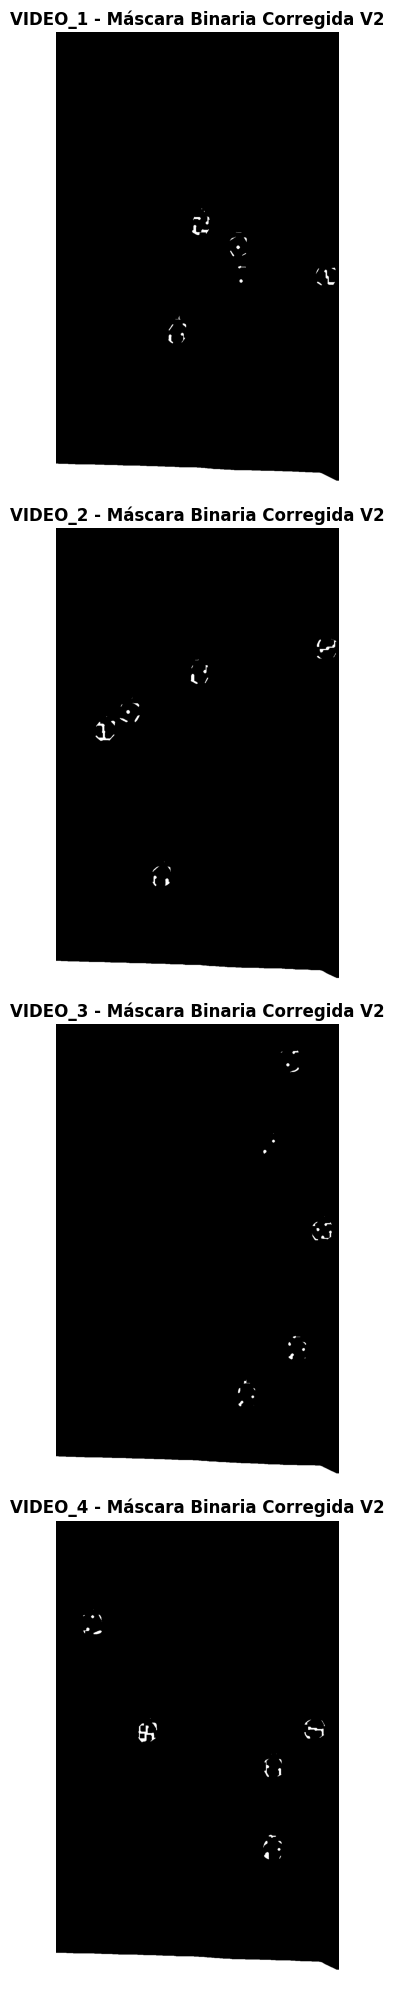

In [ ]:
mascaras_diagnostico_v2 = {}
fig, axes = plt.subplots(4, 1, figsize=(10, 20))

for idx, (key, data) in enumerate(videos_data.items()):
    ax = axes[idx]
    
    stable_idx = data.get("stable_frame_idx")
    if stable_idx is None: continue
        
    frame = data["frames"][stable_idx]
    h_orig, w_orig, _ = frame.shape
    
    # 1. Recorte físico estricto de la zona verde
    y_inicio = int(h_orig * 0.05)
    y_fin = int(h_orig * 0.76)
    x_inicio = int(w_orig * 0.05)
    x_fin = int(w_orig * 0.95)
    roi_frame = frame[y_inicio:y_fin, x_inicio:x_fin].copy()
    
    # 2. Suavizado de mediana para amalgamar los puntos
    median = cv2.medianBlur(roi_frame, 11)
    
    # 3. Pasar a HSV
    hsv = cv2.cvtColor(median, cv2.COLOR_BGR2HSV)
    _, s, _ = cv2.split(hsv)
    
    # 4.Umbral INVERTIDO (BINARY_INV) 
    # Bajamos un poco el umbral a 115 para capturar mejor todo el cuerpo del dado
    _, thresh = cv2.threshold(s, 115, 255, cv2.THRESH_BINARY_INV)
    
    # 5. Cierre morfológico más potente para rellenar los puntitos internos por completo
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    
    # Guardamos la máscara corregida
    mascaras_diagnostico_v2[key] = thresh
    
    # Mostrar el resultado del diagnóstico corregido
    ax.imshow(thresh, cmap='gray')
    ax.set_title(f"{key.upper()} - Máscara Binaria Corregida V2", fontsize=12, fontweight='bold')
    ax.axis("off")

plt.tight_layout()
plt.show()

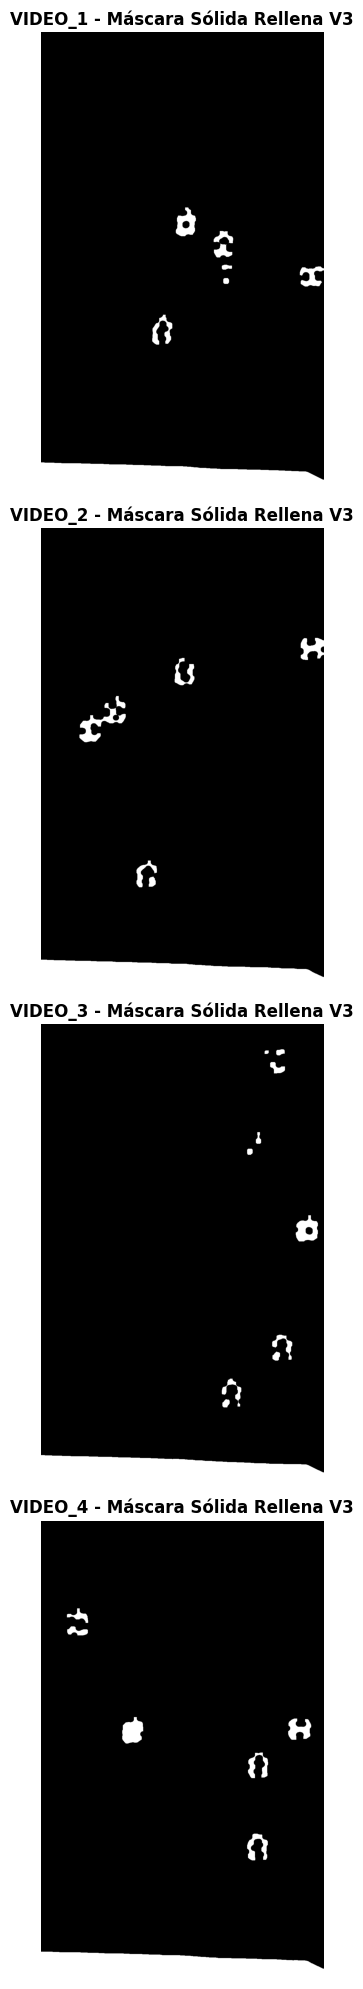

In [ ]:
mascaras_diagnostico_v3 = {}
fig, axes = plt.subplots(4, 1, figsize=(10, 20))

for idx, (key, data) in enumerate(videos_data.items()):
    ax = axes[idx]
    
    stable_idx = data.get("stable_frame_idx")
    if stable_idx is None: continue
        
    frame = data["frames"][stable_idx]
    h_orig, w_orig, _ = frame.shape
    
    # 1. Recorte físico estricto de la zona verde
    y_inicio = int(h_orig * 0.05)
    y_fin = int(h_orig * 0.76)
    x_inicio = int(w_orig * 0.05)
    x_fin = int(w_orig * 0.95)
    roi_frame = frame[y_inicio:y_fin, x_inicio:x_fin].copy()
    
    # 2. Suavizado de mediana para amalgamar
    median = cv2.medianBlur(roi_frame, 11)
    
    # 3. Pasar a HSV
    hsv = cv2.cvtColor(median, cv2.COLOR_BGR2HSV)
    _, s, _ = cv2.split(hsv)
    
    # 4. Umbral base (mantenemos el BINARY_INV que limpió el fondo)
    _, thresh = cv2.threshold(s, 115, 255, cv2.THRESH_BINARY_INV)
    
    # ------------------------------------------------------------------
    # MORFOLOGÍA PARA RELLENAR HOYOS (DILATAR + CERRAR)
    # ------------------------------------------------------------------
    # Primero dilatamos un poco para expandir las paredes de los "anillos"
    kernel_dilate = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    thresh_dilated = cv2.dilate(thresh, kernel_dilate, iterations=2)
    
    # Luego aplicamos un cierre morfológico gigante para sepultar los huecos internos
    kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (21, 21))
    thresh_filled = cv2.morphologyEx(thresh_dilated, cv2.MORPH_CLOSE, kernel_close)
    
    # Guardamos la máscara para el paso final
    mascaras_diagnostico_v3[key] = thresh_filled
    
    # Mostrar el resultado intermedio
    ax.imshow(thresh_filled, cmap='gray')
    ax.set_title(f"{key.upper()} - Máscara Sólida Rellena V3", fontsize=12, fontweight='bold')
    ax.axis("off")

plt.tight_layout()
plt.show()

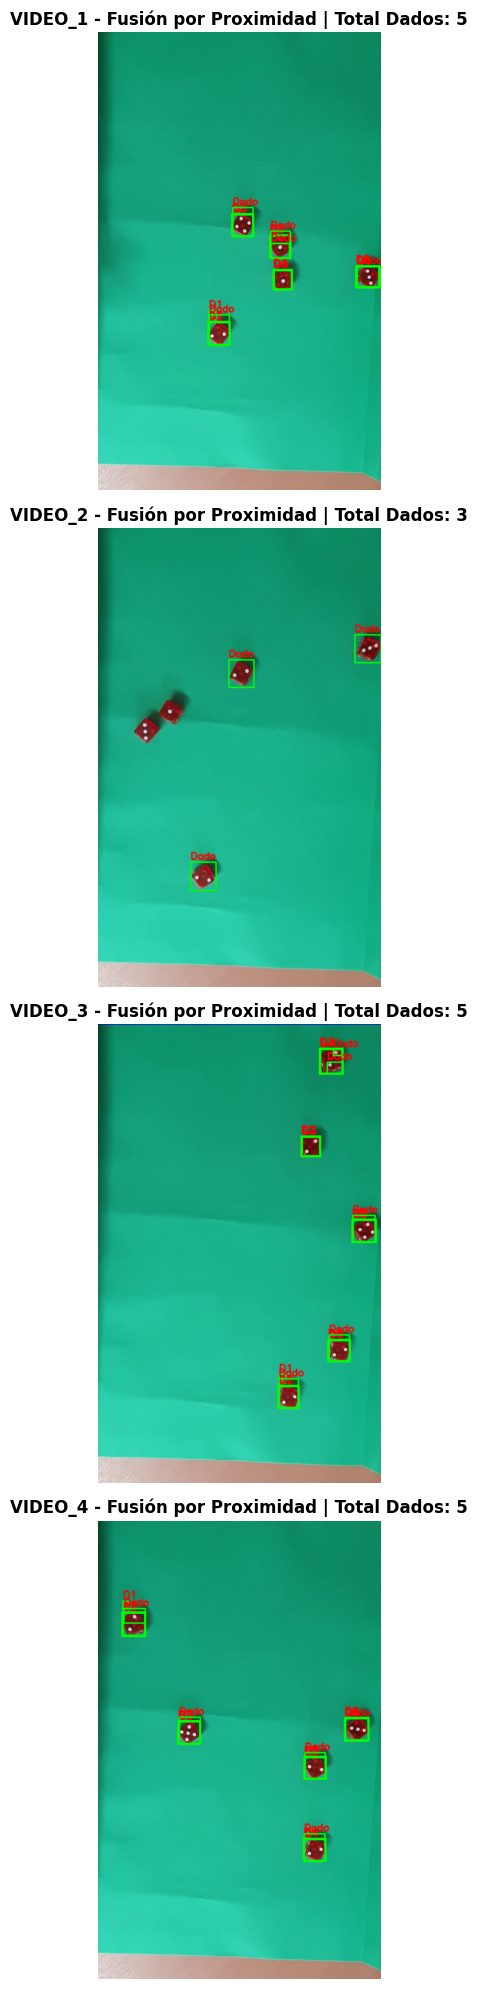

In [47]:
# --- CONFIGURACIÓN DE GEOMETRÍA FINAL ---
MIN_AREA_DADO = 400    
MAX_AREA_DADO = 12000
DISTANCIA_MAX_FUSION = 45  # Distancia máxima en píxeles para considerar que pertenecen al mismo dado

dados_por_video = {}
fig, axes = plt.subplots(4, 1, figsize=(10, 20))

for idx, (key, data) in enumerate(videos_data.items()):
    ax = axes[idx]
    
    stable_idx = data.get("stable_frame_idx")
    if stable_idx is None: continue
        
    frame = data["frames"][stable_idx]
    h_orig, w_orig, _ = frame.shape
    
    # 1. Recorte físico estricto de la zona verde
    y_inicio = int(h_orig * 0.05)
    y_fin = int(h_orig * 0.76)
    x_inicio = int(w_orig * 0.05)
    x_fin = int(w_orig * 0.95)
    roi_frame = frame[y_inicio:y_fin, x_inicio:x_fin].copy()
    orig_roi_copy = roi_frame.copy()
    
    # 2. Máscara base (Mediana -> HSV -> Thresh -> Morfología)
    median = cv2.medianBlur(roi_frame, 11)
    hsv = cv2.cvtColor(median, cv2.COLOR_BGR2HSV)
    _, s, _ = cv2.split(hsv)
    _, thresh = cv2.threshold(s, 115, 255, cv2.THRESH_BINARY_INV)
    
    kernel_dilate = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    thresh_dilated = cv2.dilate(thresh, kernel_dilate, iterations=2)
    kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (21, 21))
    thresh_filled = cv2.morphologyEx(thresh_dilated, cv2.MORPH_CLOSE, kernel_close)
    
    # 3. Relleno geométrico de los contornos huecos
    contours_huecos, _ = cv2.findContours(thresh_filled, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    mascara_maciza = np.zeros_like(thresh_filled)
    
    for cnt in contours_huecos:
        if cv2.contourArea(cnt) > 100:
            cv2.drawContours(mascara_maciza, [cnt], -1, 255, -1)
    
    # 4. Detección inicial de cajas candidatas
    contours_finales, _ = cv2.findContours(mascara_maciza, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    candidatos_boxes = []
    for cnt in contours_finales:
        area = cv2.contourArea(cnt)
        if MIN_AREA_DADO < area < MAX_AREA_DADO:
            x, y, w, h = cv2.boundingRect(cnt)
            aspect_ratio = float(w) / h
            if 0.5 <= aspect_ratio <= 1.8:
                candidatos_boxes.append([x, y, w, h])
                
    # ------------------------------------------------------------------
    # FUSIÓN POR PROXIMIDAD DE CENTROS
    # ------------------------------------------------------------------
    dice_boxes = []
    
    while len(candidatos_boxes) > 0:
        box = candidatos_boxes.pop(0)
        x1, y1, w1, h1 = box
        centro_x1 = x1 + w1 // 2
        centro_y1 = y1 + h1 // 2
        
        duplicado = False
        for i, de_lista in enumerate(dice_boxes):
            x2, y2, w2, h2 = de_lista
            centro_x2 = x2 + w2 // 2
            centro_y2 = y2 + h2 // 2
            
            # Calculamos la distancia euclidea entre los centros de ambas cajas
            distancia = np.sqrt((centro_x1 - centro_x2)**2 + (centro_y1 - centro_y2)**2)
            
            # Si están peligrosamente cerca, se trata del mismo dado fragmentado
            if distancia < DISTANCIA_MAX_FUSION:
                # Combinamos las cajas expandiendo los límites exteriores
                x_min = min(x1, x2)
                y_min = min(y1, y2)
                x_max = max(x1 + w1, x2 + w2)
                y_max = max(y1 + h1, y2 + h2)
                
                dice_boxes[i] = [x_min, y_min, x_max - x_min, y_max - y_min]
                duplicado = True
                break
                
        if not duplicado:
            dice_boxes.append(box)
            
    # 5. Guardar recortes y dibujar resultados finales limpios
    recortes = []
    for (x, y, w, h) in dice_boxes:
        recorte = orig_roi_copy[y:y+h, x:x+w]
        recortes.append(recorte)
        
        cv2.rectangle(roi_frame, (x, y), (x + w, y + h), (0, 255, 0), 4)
        cv2.putText(roi_frame, "Dado", (x, y - 10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 1.1, (0, 0, 255), 3)
        
    dados_por_video[key] = {
        "boxes": dice_boxes,
        "recortes": recortes
    }
    
    # Mostrar el frame procesado final en el subplot
    ax.imshow(cv2.cvtColor(roi_frame, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{key.upper()} - Fusión por Proximidad | Total Dados: {len(dice_boxes)}", fontsize=12, fontweight='bold')
    ax.axis("off")

plt.tight_layout()
plt.show()


--------------------------------------------------
 CALCULANDO TIRADA: VIDEO_1
--------------------------------------------------
 -> Dado 1: Detectado valor 2
 -> Dado 2: Detectado valor 3
 -> Dado 3: Detectado valor 1
 -> Dado 4: Detectado valor 0
 -> Dado 5: Detectado valor 4


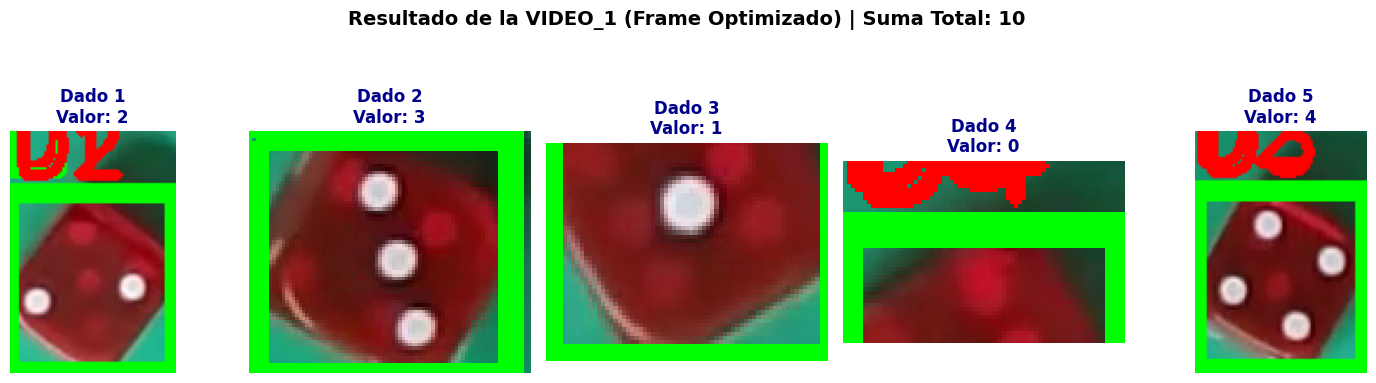


--------------------------------------------------
 CALCULANDO TIRADA: VIDEO_2
--------------------------------------------------
 -> Dado 1: Detectado valor 2
 -> Dado 2: Detectado valor 2
 -> Dado 3: Detectado valor 5


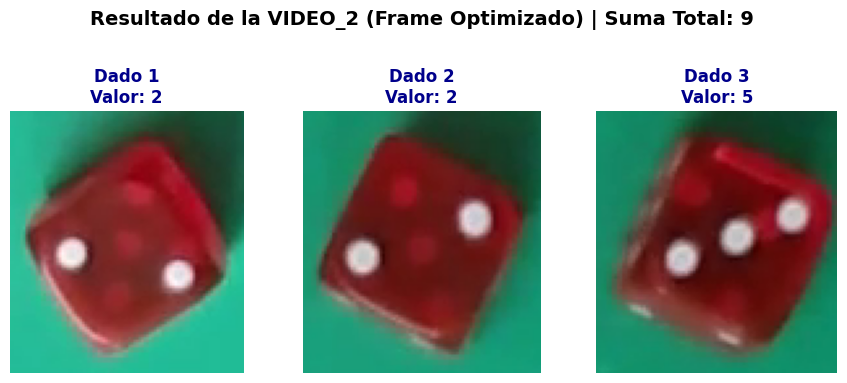


--------------------------------------------------
 CALCULANDO TIRADA: VIDEO_3
--------------------------------------------------
 -> Dado 1: Detectado valor 4
 -> Dado 2: Detectado valor 5
 -> Dado 3: Detectado valor 5
 -> Dado 4: Detectado valor 4
 -> Dado 5: Detectado valor 1


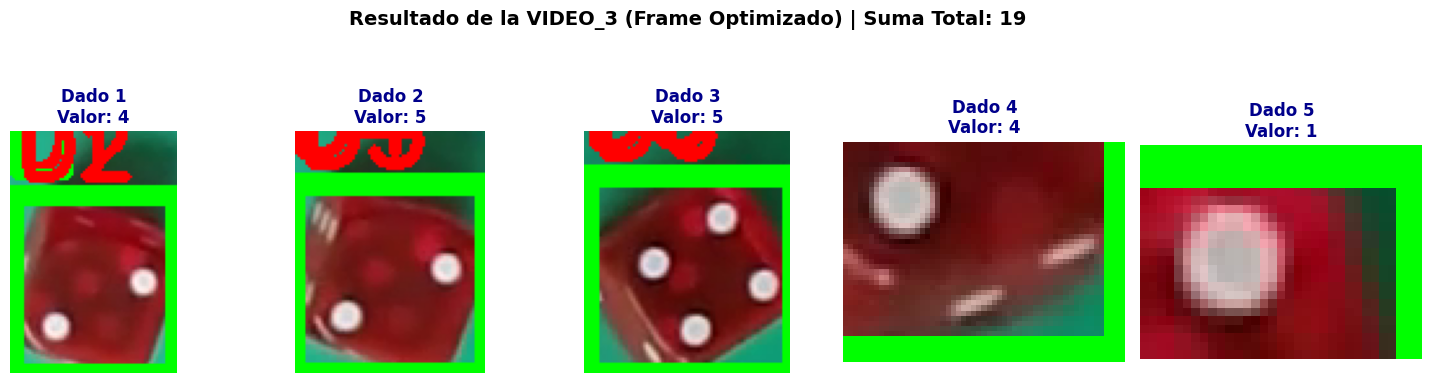


--------------------------------------------------
 CALCULANDO TIRADA: VIDEO_4
--------------------------------------------------
 -> Dado 1: Detectado valor 3
 -> Dado 2: Detectado valor 2
 -> Dado 3: Detectado valor 3
 -> Dado 4: Detectado valor 5
 -> Dado 5: Detectado valor 2


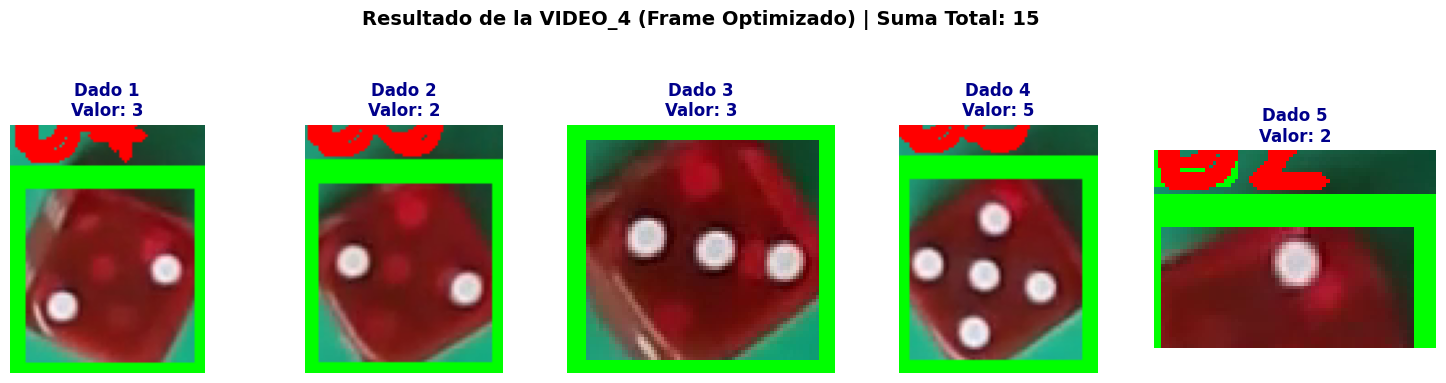

In [ ]:
# --- CONFIGURACIÓN DE GEOMETRÍA FINAL ---
MIN_AREA_DADO = 400    
MAX_AREA_DADO = 12000
DISTANCIA_MAX_FUSION = 45  

# FORZAMOS EL FRAME 60 PARA EL VIDEO 2 (como pediste para evitar el movimiento)
if "video_2" in videos_data:
    videos_data["video_2"]["stable_frame_idx"] = 60

dados_por_video = {}

# ==================================================================
# ETAPA 1: DETECCIÓN LIMPIA Y EXTRACCIÓN DE RECORTES (Ajustada)
# ==================================================================
for key, data in videos_data.items():
    stable_idx = data.get("stable_frame_idx")
    if stable_idx is None: continue
        
    frame = data["frames"][stable_idx]
    h_orig, w_orig, _ = frame.shape
    
    y_inicio = int(h_orig * 0.05)
    y_fin = int(h_orig * 0.76)
    x_inicio = int(w_orig * 0.05)
    x_fin = int(w_orig * 0.95)
    roi_frame = frame[y_inicio:y_fin, x_inicio:x_fin].copy()
    
    # Guardamos una copia pura del ROI SIN letras ni rectángulos para extraer los dados limpios
    roi_limpio = roi_frame.copy()
    
    # Procesamiento de máscara
    median = cv2.medianBlur(roi_frame, 11)
    hsv = cv2.cvtColor(median, cv2.COLOR_BGR2HSV)
    _, s, _ = cv2.split(hsv)
    _, thresh = cv2.threshold(s, 115, 255, cv2.THRESH_BINARY_INV)
    
    kernel_dilate = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    thresh_dilated = cv2.dilate(thresh, kernel_dilate, iterations=2)
    kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (21, 21))
    thresh_filled = cv2.morphologyEx(thresh_dilated, cv2.MORPH_CLOSE, kernel_close)
    
    contours_huecos, _ = cv2.findContours(thresh_filled, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    mascara_maciza = np.zeros_like(thresh_filled)
    
    for cnt in contours_huecos:
        if cv2.contourArea(cnt) > 100:
            cv2.drawContours(mascara_maciza, [cnt], -1, 255, -1)
    
    contours_finales, _ = cv2.findContours(mascara_maciza, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    candidatos_boxes = []
    for cnt in contours_finales:
        area = cv2.contourArea(cnt)
        if MIN_AREA_DADO < area < MAX_AREA_DADO:
            x, y, w, h = cv2.boundingRect(cnt)
            aspect_ratio = float(w) / h
            if 0.5 <= aspect_ratio <= 1.8:
                candidatos_boxes.append([x, y, w, h])
                
    # Fusión por proximidad
    dice_boxes = []
    while len(candidatos_boxes) > 0:
        box = candidatos_boxes.pop(0)
        x1, y1, w1, h1 = box
        centro_x1 = x1 + w1 // 2
        centro_y1 = y1 + h1 // 2
        duplicado = False
        for i, de_lista in enumerate(dice_boxes):
            x2, y2, w2, h2 = de_lista
            centro_x2 = x2 + w2 // 2
            centro_y2 = y2 + h2 // 2
            distancia = np.sqrt((centro_x1 - centro_x2)**2 + (centro_y1 - centro_y2)**2)
            if distancia < DISTANCIA_MAX_FUSION:
                x_min = min(x1, x2)
                y_min = min(y1, y2)
                x_max = max(x1 + w1, x2 + w2)
                y_max = max(y1 + h1, y2 + h2)
                dice_boxes[i] = [x_min, y_min, x_max - x_min, y_max - y_min]
                duplicado = True
                break
        if not duplicado:
            dice_boxes.append(box)
            
    # Extraer recortes puros del roi_limpio (libres de texto rojo previo)
    recortes = []
    for (x, y, w, h) in dice_boxes:
        # Añadimos un pequeño margen extra de 2 píxeles para no cortar los puntos del borde
        x_pad = max(0, x - 2)
        y_pad = max(0, y - 2)
        w_pad = min(roi_limpio.shape[1] - x_pad, w + 4)
        h_pad = min(roi_limpio.shape[0] - y_pad, h + 4)
        
        recorte_puro = roi_limpio[y_pad:y_pad+h_pad, x_pad:x_pad+w_pad]
        recortes.append(recorte_puro)
        
    dados_por_video[key] = {
        "boxes": dice_boxes,
        "recortes": recortes
    }

# ==================================================================
# ETAPA 2: PIPELINE ADAPTATIVO DE CONTEO DE PUNTOS
# ==================================================================
def contar_puntos_adaptativo(dice_img):
    if dice_img is None or dice_img.size == 0: return 0
    
    gray = cv2.cvtColor(dice_img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    
    # Umbral adaptativo: calcula el umbral bloque por bloque, ideal para dados rotados con brillos
    thresh = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                   cv2.THRESH_BINARY, 11, -10)
    
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    puntos = 0
    for cnt in contours:
        area = cv2.contourArea(cnt)
        # Filtro de tamaño del punto blanco
        if 5 <= area <= 200:
            # Filtro de circularidad para descartar esquinas brillantes reflejadas
            perimetro = cv2.arcLength(cnt, True)
            if perimetro == 0: continue
            circularidad = 4 * np.pi * area / (perimetro ** 2)
            if circularidad > 0.4:  # Permite círculos levemente deformados por la perspectiva
                puntos += 1
    return puntos

# ==================================================================
# ETAPA 3: MOSTRAR RESULTADOS FINALES POR PANTALLA
# ==================================================================
for key, data in dados_por_video.items():
    recortes = data.get("recortes", [])
    if len(recortes) == 0: continue
        
    fig, axes = plt.subplots(1, len(recortes), figsize=(3 * len(recortes), 3.5))
    if len(recortes) == 1: axes = [axes]
        
    valores_tirada = []

    print(f"\n{'-'*50}\n CALCULANDO TIRADA: {key.upper()}\n{'-'*50}")
    
    for i, dado in enumerate(recortes):
        num_puntos = contar_puntos_adaptativo(dado)
        valores_tirada.append(num_puntos)
        print(f" -> Dado {i+1}: Detectado valor {num_puntos}")
        
        axes[i].imshow(cv2.cvtColor(dado, cv2.COLOR_BGR2RGB))
        axes[i].set_title(f"Dado {i+1}\nValor: {num_puntos}", fontsize=12, fontweight='bold', color='darkblue')
        axes[i].axis("off")
        
    plt.suptitle(f"Resultado de la {key.upper()} (Frame Optimizado) | Suma Total: {sum(valores_tirada)}", 
                 fontsize=14, fontweight='bold', y=1.08)
    plt.tight_layout()
    plt.show()

In [42]:
# Mostrar resultados (B)


In [41]:
# Generar frame con etiquetas (C)


In [43]:
# Generar video final
